In [1]:
import os
import copy
import random
import collections
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import itertools
import seaborn as sns

# Scikit-learn Preprocessing, Splitting, and Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, matthews_corrcoef, precision_recall_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

# Imbalanced Learning Frameworks
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Machine Learning & Deep Learning Frameworks
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Explainable AI (XAI) Libraries
import shap
import lime
import lime.lime_tabular
from tqdm import tqdm

import preprocess



In [2]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure fully deterministic behavior in PyTorch backends
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
filepath = "data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
df = preprocess.load_and_clean_dataset(filepath)

#change to a binary label
df['Label'] = df['Label'].astype(str).str.strip().str.upper()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = df.drop(columns=['Label'])
y = df['Label'].values

print(f"[*] Cleaned Feature matrix shape: {X.shape}")
print(f"[*] Target distribution: Benign (0) = {np.sum(y == 0)}, Attack (1) = {np.sum(y == 1)}")


[*] Loading raw dataset from: data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
[*] Dataset Ingestion & Cleaning Audit:
    -> Raw Rows Ingested:          458,968
    -> Empty CSV Padding Purged:   288,602
    -> Valid Network Flows:        170,366
    -> Invalid Flows Dropped (Inf/NaN): 135
    -> Final Usable Flows:         170,231
[*] Cleaned Feature matrix shape: (170231, 78)
[*] Target distribution: Benign (0) = 168051, Attack (1) = 2180


In [4]:
# Step A: Split off 30% of the data into a temporary block, stratifying to preserve class ratios
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Step B: Split the temporary block evenly to yield a 15% Validation set and a 15% Test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("==================== DATA SPLIT SUMMARY ====================")
print(f"Training Set (70%):   X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation Set (15%): X = {X_val.shape}, y = {y_val.shape}")
print(f"Test Set (15%):       X = {X_test.shape}, y = {y_test.shape}")

==================== DATA SPLIT SUMMARY ====================
Training Set (70%):   X = (119161, 78), y = (119161,)
Validation Set (15%): X = (25535, 78), y = (25535,)
Test Set (15%):       X = (25535, 78), y = (25535,)


In [5]:
# 1. Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 2. Correlated Feature Groups (Supervisor point 15 & 16)
corr_matrix = X_train_scaled.corr(method="spearman")
# Get upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find columns with correlation > 0.90
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.90)]

print(f"[*] Features identified for potential removal (>0.90 correlation): {len(to_drop)}")

[*] Features identified for potential removal (>0.90 correlation): 39


In [6]:
# Initialize SMOTE-Tomek with a fixed seed for strict reproducibility
smote_tomek = SMOTETomek(random_state=42)

# Resample ONLY the training set
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_scaled,
    y_train
)

print("================= RESAMPLING SUMMARY =================")
print(f"Original Training Class Ratios: 0 = {np.sum(y_train == 0)}, 1 = {np.sum(y_train == 1)}")
print(f"Resampled Training Data Shape:  X = {X_train_resampled.shape}, y = {y_train_resampled.shape}")
print(f"Resampled Training Class Ratios: 0 = {np.sum(y_train_resampled == 0)}, 1 = {np.sum(y_train_resampled == 1)}")

================= RESAMPLING SUMMARY =================
Original Training Class Ratios: 0 = 117635, 1 = 1526
Resampled Training Data Shape:  X = (235254, 78), y = (235254,)
Resampled Training Class Ratios: 0 = 117627, 1 = 117627


In [7]:
print("[*] Initializing XGBoost Classifier...")

# Initialize XGBoost with strict reproducibility parameters
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.1,
    random_state=42,
    use_label_encoder=False,
    early_stopping_rounds=15
)

# Fit model with early stopping monitored against the validation split
xgb_model.fit(
    X_train_resampled, 
    y_train_resampled,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

print(f"[*] XGBoost training complete.")
print(f"    -> Best Iteration: {xgb_model.best_iteration}")

[*] Initializing XGBoost Classifier...


c:\Users\Moritz\Documents\Uni\bachlor_thesis\ids-xai-thesis\thesis_env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [16:48:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[*] XGBoost training complete.
    -> Best Iteration: 398


In [8]:
class BaselineDNN(nn.Module):
    def __init__(self, input_dim):
        super(BaselineDNN, self).__init__()
        
        # Layer 1: Input to Hidden 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.30)
        
        # Layer 2: Hidden 1 to Hidden 2
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.30)
        
        # Layer 3: Hidden 2 to Output Layer
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.sigmoid(self.fc3(x))
        return x

# Set calculation device backend
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_features_count = X_train_resampled.shape[1]

# Instantiate model architecture as BaselineDNN
model_dnn = BaselineDNN(input_dim=input_features_count).to(device)
print(f"[*] Baseline DNN mapped successfully onto target hardware device: {device.type.upper()}")

[*] Baseline DNN mapped successfully onto target hardware device: CPU


In [9]:
# Convert DataFrames/Arrays to PyTorch multi-dimensional tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_resampled.values),
    torch.FloatTensor(y_train_resampled).unsqueeze(1)
)
val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)
val_y_tensor = torch.FloatTensor(y_val).unsqueeze(1).to(device)

# Configure data loader iterations
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Set optimizer equations and standard binary loss scoring
criterion = nn.BCELoss()
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001)

# Early Stopping parameters
patience = 10
best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0
max_epochs = 150

print("[*] Initiating DNN optimization loop...")
for epoch in range(1, max_epochs + 1):
    model_dnn.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model_dnn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        
    # Validation Evaluation Phase (Zero Leakage Check)
    model_dnn.eval()
    with torch.no_grad():
        val_outputs = model_dnn(val_x_tensor)
        val_loss = criterion(val_outputs, val_y_tensor).item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    
    # Early stopping criteria tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model_dnn.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"[*] Early stopping triggered at Epoch {epoch}. Overfitting threshold neutralized.")
        break

# Roll back parameter matrix states to the optimal captured validation validation loss weights
if best_model_weights is not None:
    model_dnn.load_state_dict(best_model_weights)
print(f"[*] Restored optimal model configurations. Best Validation Loss: {best_val_loss:.5f}")

C:\Users\Moritz\AppData\Local\Temp\ipykernel_24288\4040257355.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  val_x_tensor = torch.FloatTensor(X_val_scaled.values).to(device)


[*] Initiating DNN optimization loop...
[*] Early stopping triggered at Epoch 21. Overfitting threshold neutralized.
[*] Restored optimal model configurations. Best Validation Loss: 0.04361


In [10]:
# Helper function to generate clean inference probability matrices from our DNN
def get_dnn_probabilities(df_input):
    model_dnn.eval()
    with torch.no_grad():
        tensor_input = torch.FloatTensor(df_input.values).to(device)
        probs = model_dnn(tensor_input).cpu().numpy().flatten()
    return probs

# Step A: Collect raw feature inference array probabilities from validation subsets
xgb_val_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]
dnn_val_probs = get_dnn_probabilities(X_val_scaled)

# Step B: Declare target tuning thresholds range
thresholds_pool = np.arange(0.50, 0.96, 0.05)

best_xgb_threshold = 0.50
best_xgb_f1 = 0.0
best_dnn_threshold = 0.50
best_dnn_f1 = 0.0

print("================= VAL THRESHOLD CALIBRATION =================")
for t in thresholds_pool:
    # Evaluate XGBoost arrays
    xgb_preds = (xgb_val_probs >= t).astype(int)
    xgb_f1 = f1_score(y_val, xgb_preds, zero_division=0)
    if xgb_f1 > best_xgb_f1:
        best_xgb_f1 = xgb_f1
        best_xgb_threshold = t
        
    # Evaluate DNN arrays
    dnn_preds = (dnn_val_probs >= t).astype(int)
    dnn_f1 = f1_score(y_val, dnn_preds, zero_division=0)
    if dnn_f1 > best_dnn_f1:
        best_dnn_f1 = dnn_f1
        best_dnn_threshold = t
        
    print(f"Threshold: {t:.2f} | XGB F1: {xgb_f1:.4f} | DNN F1: {dnn_f1:.4f}")

print("\n[*] Calibrated Decision Parameter Options Frozen:")
print(f"    -> Selected Frozen XGBoost Threshold: {best_xgb_threshold:.2f} (Val F1: {best_xgb_f1:.4f})")
print(f"    -> Selected Frozen DNN Threshold:     {best_dnn_threshold:.2f} (Val F1: {best_dnn_f1:.4f})")

================= VAL THRESHOLD CALIBRATION =================
Threshold: 0.50 | XGB F1: 0.9954 | DNN F1: 0.5195
Threshold: 0.55 | XGB F1: 0.9954 | DNN F1: 0.5304
Threshold: 0.60 | XGB F1: 0.9954 | DNN F1: 0.5450
Threshold: 0.65 | XGB F1: 0.9954 | DNN F1: 0.6054
Threshold: 0.70 | XGB F1: 0.9954 | DNN F1: 0.6681
Threshold: 0.75 | XGB F1: 0.9970 | DNN F1: 0.7687
Threshold: 0.80 | XGB F1: 0.9970 | DNN F1: 0.8626
Threshold: 0.85 | XGB F1: 0.9969 | DNN F1: 0.8555
Threshold: 0.90 | XGB F1: 0.9969 | DNN F1: 0.8547
Threshold: 0.95 | XGB F1: 0.9985 | DNN F1: 0.8571

[*] Calibrated Decision Parameter Options Frozen:
    -> Selected Frozen XGBoost Threshold: 0.95 (Val F1: 0.9985)
    -> Selected Frozen DNN Threshold:     0.80 (Val F1: 0.8626)


In [11]:
# Step A: Extract test predictions using frozen configurations
xgb_test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
dnn_test_probs = get_dnn_probabilities(X_test_scaled)

xgb_test_preds = (xgb_test_probs >= best_xgb_threshold).astype(int)
dnn_test_preds = (dnn_test_probs >= best_dnn_threshold).astype(int)

# Step B: Print formal validation summaries for your thesis report
print("=================== FINAL FROZEN XGBOOST REPORT ===================")
print(f"Applied Decision Threshold: {best_xgb_threshold:.2f}")
print(confusion_matrix(y_test, xgb_test_preds))
print(classification_report(y_test, xgb_test_preds, digits=4))

print("\n==================== FINAL FROZEN DNN REPORT ====================")
print(f"Applied Decision Threshold: {best_dnn_threshold:.2f}")
print(confusion_matrix(y_test, dnn_test_preds))
print(classification_report(y_test, dnn_test_preds, digits=4))

=================== FINAL FROZEN XGBOOST REPORT ===================
Applied Decision Threshold: 0.95
[[25207     1]
 [    4   323]]
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     25208
           1     0.9969    0.9878    0.9923       327

    accuracy                         0.9998     25535
   macro avg     0.9984    0.9939    0.9961     25535
weighted avg     0.9998    0.9998    0.9998     25535


==================== FINAL FROZEN DNN REPORT ====================
Applied Decision Threshold: 0.80
[[25126    82]
 [   19   308]]
              precision    recall  f1-score   support

           0     0.9992    0.9967    0.9980     25208
           1     0.7897    0.9419    0.8591       327

    accuracy                         0.9960     25535
   macro avg     0.8945    0.9693    0.9286     25535
weighted avg     0.9966    0.9960    0.9962     25535



In [12]:
# Standardized probability wrappers for the explainers
def xgb_predict_proba_wrapper(x_numpy):
    # Map numpy matrix rows directly back to pandas format to preserve column naming indices natively
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    return xgb_model.predict_proba(df_temp)

def dnn_predict_proba_wrapper(x_numpy):
    df_temp = pd.DataFrame(x_numpy, columns=X_train_scaled.columns)
    probs_class_1 = get_dnn_probabilities(df_temp)
    probs_class_0 = 1.0 - probs_class_1
    return np.column_stack((probs_class_0, probs_class_1))

# Step 5 Explanation Stability and Locality Audit

In [13]:
#Standardized LIME Neighborhood Sensitivity Audit
y_test_np = y_test.values if isinstance(y_test, pd.Series) else np.array(y_test)
tp_indices = np.where((y_test_np == 1) & (xgb_test_preds == 1))[0]

print(f"[+] Isolated {len(tp_indices)} True Positive attack records using pre-calculated test predictions.")

# Representative evaluation cohort of 10 attack alerts
stability_cohort_idx = tp_indices[:10]
X_cohort = X_test_scaled.iloc[stability_cohort_idx].values 
train_data_np = X_train_scaled.values if isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled

# Audit key configurations: Primary Continuous (2.5), Sensitivity Discrete (1.5), and Wider Perturbations
sensitivity_configs = [
    {'name': 'Primary (Cont KW=2.5)', 'disc': False, 'kw': 2.5},
    {'name': 'Sensitivity (Disc KW=1.5)', 'disc': True, 'kw': 1.5},
    {'name': 'Continuous (KW=1.0)', 'disc': False, 'kw': 1.0},
    {'name': 'Continuous (KW=5.0)', 'disc': False, 'kw': 5.0}
]

lime_sensitivity_records = []
print("[*] Launching Standardized LIME Neighborhood Sensitivity Audit...")

for cfg in sensitivity_configs:
    print(f"    Evaluating Config: {cfg['name']}")
    
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=train_data_np,
        feature_names=X_train.columns,
        class_names=['Benign', 'Attack'],
        mode='classification',
        discretize_continuous=cfg['disc'],
        kernel_width=cfg['kw'],
        random_state=42
    )
    
    for i, instance_idx in enumerate(stability_cohort_idx):
        instance = X_cohort[i]
        
        exp = explainer_lime.explain_instance(
            data_row=instance,
            predict_fn=xgb_predict_proba_wrapper,
            num_features=len(X_train.columns),
            labels=(1,)
        )
        
        r2_fidelity = exp.score
        raw_local = exp.local_exp[1]
        sorted_local = sorted(raw_local, key=lambda x: abs(x[1]), reverse=True)
        top_10_indices = [idx for idx, _ in sorted_local[:10]]
        top_10_features = [X_train.columns[idx] for idx in top_10_indices]
        
        lime_sensitivity_records.append({
            'Config_Name': cfg['name'],
            'Discretize': cfg['disc'],
            'Kernel_Width': cfg['kw'],
            'Instance_ID': instance_idx,
            'Fidelity_R2': r2_fidelity,
            'Top_10_Features': top_10_features
        })

df_lime_kernel_audit = pd.DataFrame(lime_sensitivity_records)
print("[+] LIME neighborhood sensitivity audit complete!")

# Display aggregated summary across tested configurations
audit_summary = df_lime_kernel_audit.groupby('Config_Name').agg({
    'Fidelity_R2': ['mean', 'median', 'std']
}).round(4)
print("\n--- Neighborhood Sensitivity Summary on True Positives ---")
print(audit_summary.to_string())

[+] Isolated 323 True Positive attack records using pre-calculated test predictions.
[*] Launching Standardized LIME Neighborhood Sensitivity Audit...
    Evaluating Config: Primary (Cont KW=2.5)
    Evaluating Config: Sensitivity (Disc KW=1.5)
    Evaluating Config: Continuous (KW=1.0)
    Evaluating Config: Continuous (KW=5.0)
[+] LIME neighborhood sensitivity audit complete!

--- Neighborhood Sensitivity Summary on True Positives ---
                          Fidelity_R2                
                                 mean  median     std
Config_Name                                          
Continuous (KW=1.0)            0.0000  0.0000  0.0000
Continuous (KW=5.0)            0.0361  0.0363  0.0015
Primary (Cont KW=2.5)          0.8480  0.8496  0.0063
Sensitivity (Disc KW=1.5)      0.9759  0.9760  0.0012


In [14]:


# ==============================================================================
# 1. HELPER FUNCTIONS FOR STABILITY METRICS
# ==============================================================================

def compute_pairwise_metrics(top_k_sets, k=10):
    """
    Computes mean pairwise Top-k overlap and Jaccard similarity across seed runs.
    """
    n_seeds = len(top_k_sets)
    if n_seeds < 2:
        return 1.0, 1.0
    
    overlaps = []
    jaccards = []
    
    for set_a, set_b in itertools.combinations(top_k_sets, 2):
        intersection_len = len(set_a.intersection(set_b))
        union_len = len(set_a.union(set_b))
        
        # Top-k Overlap: |A ∩ B| / k
        overlaps.append(intersection_len / float(k))
        
        # Jaccard Similarity: |A ∩ B| / |A ∪ B|
        jaccards.append(intersection_len / float(union_len) if union_len > 0 else 1.0)
        
    return np.mean(overlaps), np.mean(jaccards)


def normalize_attributions(weights):
    """
    L1-normalizes feature attributions to make weights comparable across runs:
    w_norm = w / sum(|w_i|)
    """
    abs_sum = np.sum(np.abs(weights))
    if abs_sum == 0:
        return weights
    return weights / abs_sum


In [15]:
# ==============================================================================
# 2. SYSTEMATIC OBSERVATION SAMPLING ACROSS PREDICTION GROUPS
# ==============================================================================

def get_prediction_groups(y_true, y_pred, n_per_group=3, seed=42):
    """
    Systematically samples instances from True Positives (TP), True Negatives (TN),
    False Positives (FP), and False Negatives (FN).
    """
    np.random.seed(seed)
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    groups = {
        'True Positive (TP)': np.where((y_true_np == 1) & (y_pred_np == 1))[0],
        'True Negative (TN)': np.where((y_true_np == 0) & (y_pred_np == 0))[0],
        'False Positive (FP)': np.where((y_true_np == 0) & (y_pred_np == 1))[0],
        'False Negative (FN)': np.where((y_true_np == 1) & (y_pred_np == 0))[0]
    }
    
    sampled_indices = {}
    for group_name, idx_pool in groups.items():
        if len(idx_pool) > 0:
            sample_size = min(n_per_group, len(idx_pool))
            chosen = np.random.choice(idx_pool, size=sample_size, replace=False)
            sampled_indices[group_name] = chosen
            print(f"[*] Sampled {len(chosen)} instances for group: {group_name}")
        else:
            print(f"[!] Warning: No instances found for prediction group: {group_name}")
            
    return sampled_indices

In [16]:
#Multi-Seed Stability Loop with Standardized Continuous LIME
N_SEEDS = 10                  # Multi-seed repetition count per observation
EVAL_SEEDS = list(range(100, 100 + N_SEEDS))
N_SAMPLES_PER_GROUP = 3       # Observations sampled per confusion matrix quadrant
KERNEL_WIDTH = 2.5            # Primary continuous kernel width
DISCRETIZE_MODE = False       # Standardized Continuous Perturbation

models_to_audit = {
    'XGBoost': {
        'predict_fn': xgb_predict_proba_wrapper,
        'preds': xgb_test_preds
    },
    'DNN': {
        'predict_fn': dnn_predict_proba_wrapper,
        'preds': dnn_test_preds
    }
}

train_data_np = X_train_scaled.values
feature_names = list(X_train.columns)

master_stability_records = []
feature_frequency_records = []

print("\n" + "="*80)
print("   STARTING MULTI-SEED STABILITY AUDIT (PRIMARY CONTINUOUS LIME KW=2.5)")
print("="*80)

for model_name, model_info in models_to_audit.items():
    print(f"\n[>>>] Auditing Model Architecture: {model_name}")
    predict_fn = model_info['predict_fn']
    test_preds = model_info['preds']
    
    # Step A: Sample observations across prediction groups for this model
    sampled_cohorts = get_prediction_groups(
        y_true=y_test, 
        y_pred=test_preds, 
        n_per_group=N_SAMPLES_PER_GROUP
    )
    
    for group_name, instance_indices in sampled_cohorts.items():
        for instance_idx in instance_indices:
            data_row = X_test_scaled.iloc[instance_idx].values
            
            top_5_sets_run = []
            top_10_sets_run = []
            fidelity_scores_run = []
            normalized_attributions_run = []
            
            # Step B: Repeat explanation over multiple seeds
            for seed in EVAL_SEEDS:
                explainer = lime.lime_tabular.LimeTabularExplainer(
                    training_data=train_data_np,
                    feature_names=feature_names,
                    class_names=['Benign', 'Attack'],
                    mode='classification',
                    discretize_continuous=DISCRETIZE_MODE,
                    kernel_width=KERNEL_WIDTH,
                    random_state=seed
                )
                
                exp = explainer.explain_instance(
                    data_row=data_row,
                    predict_fn=predict_fn,
                    num_features=len(feature_names),
                    labels=(1,)
                )
                
                # Extract fidelity score (R^2)
                r2_fidelity = exp.score
                fidelity_scores_run.append(r2_fidelity)
                
                # Full feature attribution vector mapping targeting Class 1 explicitly
                local_exp = exp.local_exp[1]
                raw_attr_vector = np.zeros(len(feature_names))
                for feat_idx, weight in local_exp:
                    raw_attr_vector[feat_idx] = weight
                    
                norm_attr_vector = normalize_attributions(raw_attr_vector)
                normalized_attributions_run.append(norm_attr_vector)
                
                # Extract Top-5 and Top-10 sets
                sorted_by_abs = sorted(local_exp, key=lambda x: abs(x[1]), reverse=True)
                top_5_indices = set([idx for idx, _ in sorted_by_abs[:5]])
                top_10_indices = set([idx for idx, _ in sorted_by_abs[:10]])
                
                top_5_sets_run.append(top_5_indices)
                top_10_sets_run.append(top_10_indices)
                
                # Record feature selection frequency
                for idx in top_10_indices:
                    feature_frequency_records.append({
                        'Model': model_name,
                        'Group': group_name,
                        'Instance_ID': instance_idx,
                        'Seed': seed,
                        'Feature': feature_names[idx]
                    })
            
            # Step C: Compute aggregated stability metrics for this observation
            mean_overlap_5, mean_jaccard_5 = compute_pairwise_metrics(top_5_sets_run, k=5)
            mean_overlap_10, mean_jaccard_10 = compute_pairwise_metrics(top_10_sets_run, k=10)
            
            norm_attr_matrix = np.array(normalized_attributions_run)
            mean_norm_attr_std = np.mean(np.std(norm_attr_matrix, axis=0))
            
            master_stability_records.append({
                'Model': model_name,
                'Prediction_Group': group_name,
                'Instance_ID': instance_idx,
                'Mean_Top5_Overlap': mean_overlap_5,
                'Mean_Jaccard_5': mean_jaccard_5,
                'Mean_Top10_Overlap': mean_overlap_10,
                'Mean_Jaccard_10': mean_jaccard_10,
                'Mean_Attr_StdDev': mean_norm_attr_std,
                'Mean_LIME_Fidelity_R2': np.mean(fidelity_scores_run),
                'Min_LIME_Fidelity_R2': np.min(fidelity_scores_run),
                'Max_LIME_Fidelity_R2': np.max(fidelity_scores_run)
            })

df_stability_summary = pd.DataFrame(master_stability_records)
df_feature_freq = pd.DataFrame(feature_frequency_records)
print("[+] Multi-seed stability loop completed successfully.")


   STARTING MULTI-SEED STABILITY AUDIT (PRIMARY CONTINUOUS LIME KW=2.5)

[>>>] Auditing Model Architecture: XGBoost
[*] Sampled 3 instances for group: True Positive (TP)
[*] Sampled 3 instances for group: True Negative (TN)
[*] Sampled 1 instances for group: False Positive (FP)
[*] Sampled 3 instances for group: False Negative (FN)

[>>>] Auditing Model Architecture: DNN
[*] Sampled 3 instances for group: True Positive (TP)
[*] Sampled 3 instances for group: True Negative (TN)
[*] Sampled 3 instances for group: False Positive (FP)
[*] Sampled 3 instances for group: False Negative (FN)
[+] Multi-seed stability loop completed successfully.


In [17]:
# Aggregated Stability Report for Thesis Text
print("\n" + "="*95)
print("             EXTENDED STABILITY ANALYSIS REPORT SUMMARY (CONTINUOUS LIME KW=2.5)")
print("="*95)

group_summary = df_stability_summary.groupby(['Model', 'Prediction_Group']).agg({
    'Mean_Top5_Overlap': ['mean', 'std'],
    'Mean_Jaccard_5': ['mean', 'std'],
    'Mean_Top10_Overlap': ['mean', 'std'],
    'Mean_Jaccard_10': ['mean', 'std'],
    'Mean_Attr_StdDev': ['mean'],
    'Mean_LIME_Fidelity_R2': ['mean', 'min', 'max']
}).round(4)

print("\n--- Summary by Model & Prediction Group ---")
print(group_summary.to_string())

model_summary = df_stability_summary.groupby('Model').agg({
    'Mean_Top5_Overlap': 'mean',
    'Mean_Jaccard_5': 'mean',
    'Mean_Top10_Overlap': 'mean',
    'Mean_Jaccard_10': 'mean',
    'Mean_Attr_StdDev': 'mean',
    'Mean_LIME_Fidelity_R2': 'mean'
}).round(4)

print("\n--- Overall Model Comparison ---")
print(model_summary.to_string())


             EXTENDED STABILITY ANALYSIS REPORT SUMMARY (CONTINUOUS LIME KW=2.5)

--- Summary by Model & Prediction Group ---
                            Mean_Top5_Overlap         Mean_Jaccard_5         Mean_Top10_Overlap         Mean_Jaccard_10         Mean_Attr_StdDev Mean_LIME_Fidelity_R2                
                                         mean     std           mean     std               mean     std            mean     std             mean                  mean     min     max
Model   Prediction_Group                                                                                                                                                              
DNN     False Negative (FN)            0.8593  0.0026         0.7654  0.0043             0.7467  0.0349          0.6037  0.0445           0.0035                0.7037  0.6009  0.7567
        False Positive (FP)            0.9244  0.0308         0.8741  0.0513             0.8104  0.0064          0.6871  0.0112           0.0

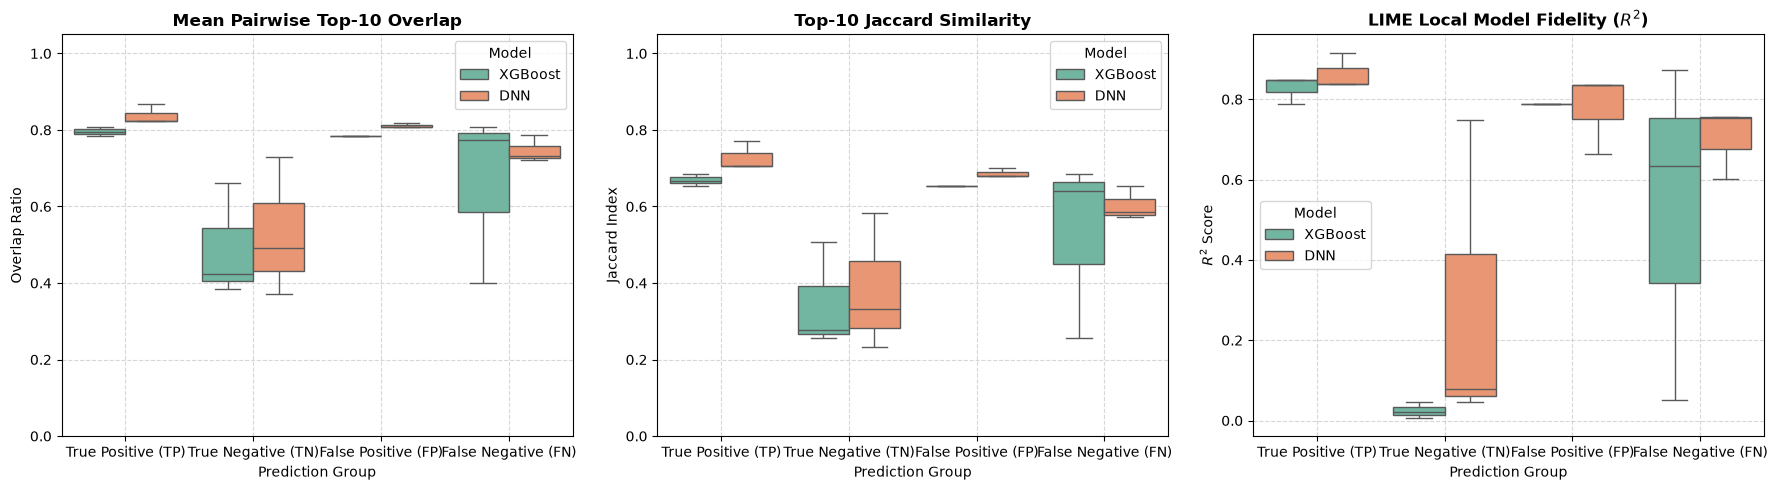

In [18]:
#Visualization of Stability Metrics (Top-10 & R^2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Pairwise Top-10 Overlap across Prediction Groups
sns.boxplot(
    data=df_stability_summary, 
    x='Prediction_Group', 
    y='Mean_Top10_Overlap', 
    hue='Model', 
    ax=axes[0], 
    palette='Set2'
)
axes[0].set_title("Mean Pairwise Top-10 Overlap", fontweight='bold')
axes[0].set_xlabel("Prediction Group")
axes[0].set_ylabel("Overlap Ratio")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: Top-10 Jaccard Similarity across Prediction Groups
sns.boxplot(
    data=df_stability_summary, 
    x='Prediction_Group', 
    y='Mean_Jaccard_10', 
    hue='Model', 
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title("Top-10 Jaccard Similarity", fontweight='bold')
axes[1].set_xlabel("Prediction Group")
axes[1].set_ylabel("Jaccard Index")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, linestyle="--", alpha=0.5)

# Plot 3: LIME Local Model Fidelity (R^2)
sns.boxplot(
    data=df_stability_summary, 
    x='Prediction_Group', 
    y='Mean_LIME_Fidelity_R2', 
    hue='Model', 
    ax=axes[2], 
    palette='Set2'
)
axes[2].set_title("LIME Local Model Fidelity ($R^2$)", fontweight='bold')
axes[2].set_xlabel("Prediction Group")
axes[2].set_ylabel("$R^2$ Score")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()